In [1]:
import numpy as np,  pandas as pd 
import matplotlib.pyplot as plt, seaborn as sns
import warnings 
warnings.filterwarnings('ignore') 
import statsmodels 
import statsmodels.api as sm 
import sklearn 
from sklearn.model_selection import train_test_split 


In [2]:
advertising = pd.read_csv('advertising.csv') 
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
advertising.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
advertising.shape

(200, 4)

In [5]:
advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
# visulaization of data 

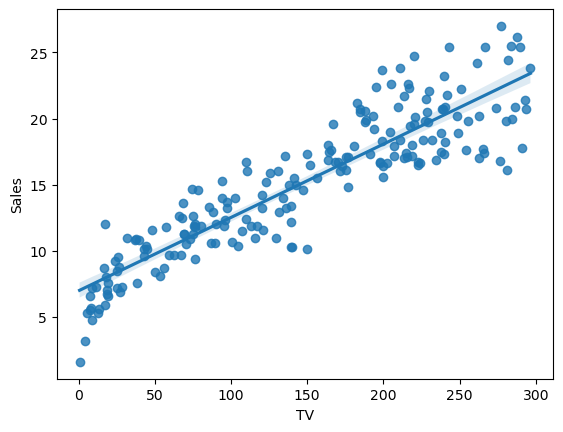

In [7]:
sns.regplot(x= 'TV', y = 'Sales', data = advertising)
plt.show()

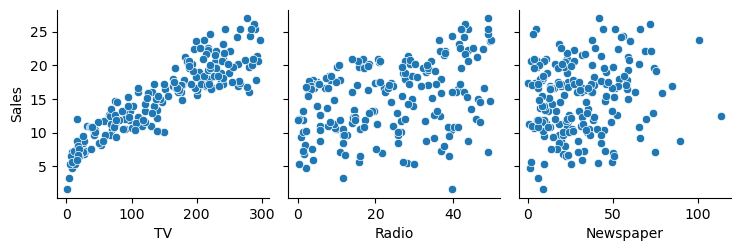

In [8]:
# the other way to see the all data from TV Radio and Newspaper all at one plase and get idea 
sns.pairplot(data= advertising, x_vars = ['TV','Radio','Newspaper'], y_vars = ['Sales']) 
plt.show()

In [9]:
advertising.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


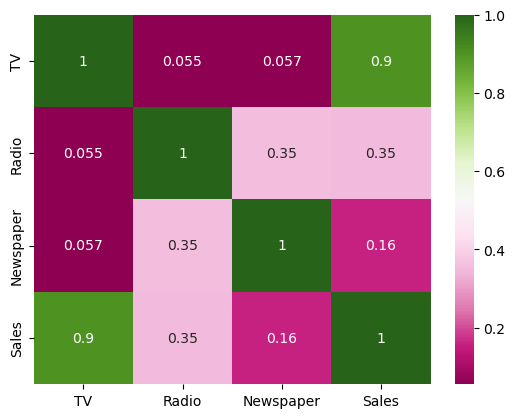

In [10]:
sns.heatmap(advertising.corr(),cmap = 'PiYG', annot = True)
plt.show()

### Step 3: Performing Simple Linear Regression

Equation of linear regression
𝑦=𝑐+𝑚1𝑥1+𝑚2𝑥2+...+𝑚𝑛𝑥𝑛
 
- 𝑦 is the response
- 𝑐 is the intercept
- 𝑚1 is the coefficient for the first feature
- 𝑚𝑛 is the coefficient for the nth feature

In our case:

𝑦=𝑐+𝑚1×𝑇𝑉
 
The  𝑚 values are called the model coefficients or model parameters.

### steps: 
- Create X and Y 
- create train and test sets ()
- evaluate the model(training set, test set) 

In [11]:
# create x and y 
X = advertising['TV'] 
y = advertising['Sales'] 


In [12]:
# train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.70, random_state = 100)
X_train.shape

# X_train, X_test, y_train, y_test
 



(140,)

In [13]:
X_train

74     213.4
3      151.5
185    205.0
26     142.9
90     134.3
       ...  
87     110.7
103    187.9
67     139.3
24      62.3
8        8.6
Name: TV, Length: 140, dtype: float64

In [14]:
# building the stats model using sm 


In [15]:
X_train_sm = sm.add_constant(X_train)
X_train_sm.head() 
 


,const,TV
74,1.0,213.4
3,1.0,151.5
185,1.0,205.0
26,1.0,142.9
90,1.0,134.3


In [16]:
#fitting the model (OLS: ordinary least squares)
lr = sm.OLS(y_train, X_train_sm )
lr_model = lr.fit()
lr_model.params

const    6.948683
TV       0.054546
dtype: float64

In [21]:
#so the above lr_model states that the for eg if we sumrize it as equation Sales = 6.94 + 0.05.TV 

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Sat, 13 May 2023   Prob (F-statistic):           1.52e-52
Time:                        23:14:30   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9487      0.385     18.068      0.000       6.188       7.709
TV             0.0545      0.002     24.722      0.000       0.050       0.059
==============================================================================
Omnibus:                        0.027   Durbin-Watson:                   2.196
Prob(Omnibus):                  0.987   Jarque-Bera (JB):                0.150
Skew:                          -0.006   Prob(JB):                        0.928
Kurtosis:                       2.840   Cond. No.                         328.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""